# Emotion Classification in Text using TF-IDF, LSTM and BERT
#### Mateusz Kantorski

### Imports

In [37]:
import numpy as np
from datasets import load_dataset
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments
)
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import torch
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from torch.nn.utils.rnn import pad_sequence
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import torch.nn as nn
from sklearn.model_selection import train_test_split
from tqdm import tqdm

### Dataset - https://huggingface.co/emotion/datasets

In [21]:
dataset = load_dataset("emotion")

label_names = dataset["train"].features["label"].names
print("Labels:", label_names)

X_train = dataset["train"]["text"]
y_train = dataset["train"]["label"]

X_test = dataset["test"]["text"]
y_test = dataset["test"]["label"]

Labels: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


### TF-IDF + LogReg

In [ ]:
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    stop_words="english"
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

logreg = LogisticRegression(
    max_iter=1000,
    n_jobs=-1
)

logreg.fit(X_train_tfidf, y_train)

y_pred = logreg.predict(X_test_tfidf)

acc_logreg = accuracy_score(y_test, y_pred)
f1_macro_logreg = f1_score(y_test, y_pred, average="macro")

print(f"TF-IDF + Logistic Regression Accuracy: {acc_logreg:.4f}")
print(f"TF-IDF + Logistic Regression Macro F1: {f1_macro_logreg:.4f}")
print("TF-IDF + Logistic Regression classification report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=dataset["train"].features["label"].names
))

e:\studies_master\MlShared\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


TF-IDF + Logistic Regression Accuracy: 0.8845
TF-IDF + Logistic Regression Macro F1: 0.8248
TF-IDF + Logistic Regression classification report:
              precision    recall  f1-score   support

     sadness       0.91      0.95      0.93       581
         joy       0.86      0.96      0.91       695
        love       0.83      0.62      0.71       159
       anger       0.90      0.83      0.87       275
        fear       0.90      0.84      0.87       224
    surprise       0.94      0.52      0.67        66

    accuracy                           0.88      2000
   macro avg       0.89      0.79      0.82      2000
weighted avg       0.89      0.88      0.88      2000



### LTSM

In [39]:
def tokenize(text):
    return text.lower().split()

counter = Counter()
for text in X_train:
    counter.update(tokenize(text))

vocab = {word: i+2 for i, (word, _) in enumerate(counter.most_common(20000))}
vocab["<PAD>"] = 0
vocab["<UNK>"] = 1

In [40]:
class EmotionDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len=50):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len

    def encode(self, text):
        tokens = tokenize(text)
        ids = [self.vocab.get(t, 1) for t in tokens][:self.max_len]
        return torch.tensor(ids)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return self.encode(self.texts[idx]), self.labels[idx]

def collate_fn(batch):
    texts, labels = zip(*batch)
    texts = pad_sequence(texts, batch_first=True)
    return texts, torch.tensor(labels)



In [ ]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42
)

train_ds = EmotionDataset(X_tr, y_tr, vocab)
val_ds   = EmotionDataset(X_val, y_val, vocab)
test_ds  = EmotionDataset(X_test, y_test, vocab)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, collate_fn=collate_fn)
val_loader   = DataLoader(val_ds, batch_size=64, collate_fn=collate_fn)
test_loader  = DataLoader(test_ds, batch_size=64, collate_fn=collate_fn)

In [42]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, num_classes=6):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            batch_first=True,
            dropout=0.3
        )
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        emb = self.embedding(x)
        _, (h_n, _) = self.lstm(emb)
        return self.fc(h_n[-1])

In [45]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_lstm = LSTMClassifier(len(vocab)).to(device)
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

EPOCHS = 15

for epoch in range(EPOCHS):
    model_lstm.train()
    total_loss, correct, total = 0, 0, 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    for x, y in loop:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model_lstm(x)
        loss = criterion(logits, y)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model_lstm.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

        loop.set_postfix(
            loss=total_loss / total,
            acc=correct / total
        )

    model_lstm.eval()
    val_correct, val_total = 0, 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            logits = model_lstm(x)
            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == y).sum().item()
            val_total += y.size(0)

    val_acc = val_correct / val_total
    print(f"Epoch: {epoch+1} accuracy: {val_acc:.4f}")


e:\studies_master\MlShared\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(
Epoch 1/15:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 1/15: 100%|██████████| 250/250 [00:01<00:00, 125.04it/s, acc=0.321, loss=0.0249]


Epoch: 1 accuracy: 0.3175


Epoch 2/15: 100%|██████████| 250/250 [00:02<00:00, 113.99it/s, acc=0.33, loss=0.0246] 


Epoch: 2 accuracy: 0.3194


...

Epoch: 13 accuracy: 0.9600


Epoch 14/15: 100%|██████████| 250/250 [00:02<00:00, 96.22it/s, acc=0.958, loss=0.00179]


Epoch: 14 accuracy: 0.9625


Epoch 15/15: 100%|██████████| 250/250 [00:02<00:00, 89.40it/s, acc=0.962, loss=0.00163]


Epoch: 15 accuracy: 0.9688


In [48]:
model_lstm.eval()
preds, labels = [], []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        logits = model_lstm(x)
        preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
        labels.extend(y.numpy())


acc_lstm = accuracy_score(labels, preds)
f1_macro_lstm = f1_score(labels, preds, average="macro")

print(f"LSTM Accuracy: {acc_lstm:.4f}")
print(f"LSTM Macro F1: {f1_macro_lstm:.4f}")
print("LSTM classification report:")
print(classification_report(
    labels,
    preds,
    target_names=dataset["train"].features["label"].names
))

LSTM Accuracy: 0.8630
LSTM Macro F1: 0.8135
LSTM classification report:
              precision    recall  f1-score   support

     sadness       0.89      0.95      0.92       581
         joy       0.90      0.87      0.88       695
        love       0.61      0.74      0.67       159
       anger       0.96      0.79      0.86       275
        fear       0.86      0.82      0.84       224
    surprise       0.66      0.74      0.70        66

    accuracy                           0.86      2000
   macro avg       0.81      0.82      0.81      2000
weighted avg       0.87      0.86      0.86      2000



### DistilBERT

In [4]:
MODEL_NAME = "distilbert-base-uncased"
NUM_LABELS = 6
OUTPUT_DIR = "models/distilbert-emotion"
BATCH_SIZE = 16
EPOCHS = 4
LR = 2e-5

In [ ]:
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

dataset = dataset.map(tokenize, batched=True)
dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

e:\studies_master\MlShared\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\matkan1\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Map: 100%|██████████| 2000/2000 [00:00<00:00, 32617.15 examples/s]


In [ ]:
model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [8]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro")
    }

In [10]:
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=LR,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=EPOCHS,
    weight_decay=0.01,
    logging_dir="./logs",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    report_to="none"
)

In [11]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["validation"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

C:\Users\matkan1\AppData\Local\Temp\ipykernel_13536\294021469.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [12]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.250500,0.216633,0.927000,0.901968
2,0.156700,0.169961,0.933500,0.905912
3,0.098600,0.155266,0.943500,0.918766
4,0.082900,0.151033,0.943000,0.921363


TrainOutput(global_step=4000, training_loss=0.20629178237915038, metrics={'train_runtime': 147.7179, 'train_samples_per_second': 433.258, 'train_steps_per_second': 27.079, 'total_flos': 2119629570048000.0, 'train_loss': 0.20629178237915038, 'epoch': 4.0})

In [13]:
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

print("Training finished. Model saved to:", OUTPUT_DIR)

Training finished. Model saved to: models/distilbert-emotion


In [14]:
test_results = trainer.evaluate(dataset["test"])
print(test_results)

{'eval_loss': 0.18192201852798462, 'eval_accuracy': 0.9255, 'eval_f1_macro': 0.8759545595182588, 'eval_runtime': 1.4763, 'eval_samples_per_second': 1354.782, 'eval_steps_per_second': 84.674, 'epoch': 4.0}


In [15]:
predictions = trainer.predict(dataset["test"])
y_true = predictions.label_ids
y_pred = np.argmax(predictions.predictions, axis=1)

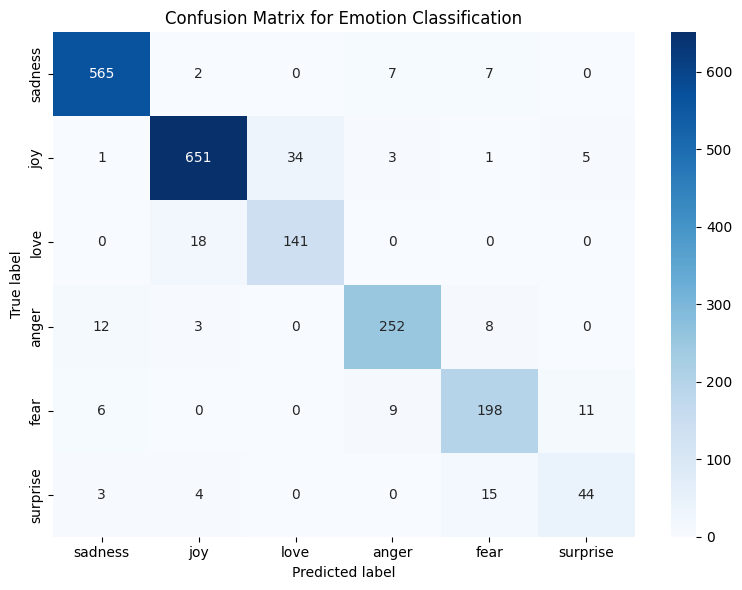

In [16]:
labels = label_names  

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels,
            yticklabels=labels)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix for Emotion Classification")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300)
plt.show()

In [17]:
print(classification_report(y_true, y_pred, target_names=labels))

              precision    recall  f1-score   support

     sadness       0.96      0.97      0.97       581
         joy       0.96      0.94      0.95       695
        love       0.81      0.89      0.84       159
       anger       0.93      0.92      0.92       275
        fear       0.86      0.88      0.87       224
    surprise       0.73      0.67      0.70        66

    accuracy                           0.93      2000
   macro avg       0.88      0.88      0.88      2000
weighted avg       0.93      0.93      0.93      2000



### Inference with DistilBERT

In [20]:
def predict_emotion(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs)
    probs = torch.softmax(outputs.logits, dim=1)
    pred_id = torch.argmax(probs, dim=1).item()
    return label_names[pred_id], probs[0][pred_id].item()

texts = [
    "I am so happy and excited today!",
    "This is the worst thing that has ever happened to me.",
    "I am afraid something bad will happen.",
    "I did not expect such things to occur.",
    "I am feeling quite sad and down.",
    "The manager was boiling inside listening to the complaints.",
    "She may look calm but she's seething."
]

for t in texts:
    label, score = predict_emotion(t)
    print(f"Text: {t}")
    print(f"Predicted emotion: {label} (confidence: {score:.2f})\n")

Text: I am so happy and excited today!
Predicted emotion: joy (confidence: 1.00)

Text: This is the worst thing that has ever happened to me.
Predicted emotion: sadness (confidence: 0.96)

Text: I am afraid something bad will happen.
Predicted emotion: fear (confidence: 1.00)

Text: I did not expect such things to occur.
Predicted emotion: anger (confidence: 0.87)

Text: I am feeling quite sad and down.
Predicted emotion: sadness (confidence: 1.00)

Text: The manager was boiling inside listening to the complaints.
Predicted emotion: anger (confidence: 1.00)

Text: She may look calm but she's seething.
Predicted emotion: joy (confidence: 1.00)

